In [225]:
import os
import datetime
import IPython
import IPython.display
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, RepeatVector, TimeDistributed

In [226]:
print("="*60)
print("STEP 0: LOAD DATA MENTAH (BELUM DI-NORMALISASI)")
print("="*60)

STEP 0: LOAD DATA MENTAH (BELUM DI-NORMALISASI)


In [105]:
path = '/content/data_training_GKU(1).csv'

In [106]:
df = pd.read_csv(path)

In [224]:
# Cek apakah data sudah dalam Z-score
print("Cek sample data:")
print(df[['temperature', 'humidity', 'pm25']].head())

# Jika mean ≈ 0 dan std ≈ 1, berarti sudah Z-score
if abs(df['temperature'].mean()) < 0.5 and abs(df['temperature'].std() - 1) < 0.2:
    print("\n🚨 WARNING: Data sudah dalam bentuk Z-score!")
    print("   Anda perlu data mentah (°C, %, μg/m³)")

    # Jika Anda punya scaler lama, reverse:
    # df[cols] = scaler_old.inverse_transform(df[cols])

    # ATAU load ulang dari sumber asli
    raise ValueError("Silakan load data mentah dari file sumber!")

Cek sample data:
   temperature  humidity      pm25
0     0.167691  0.998861  0.767396
1     0.159350  0.998861  0.755365
2     0.153644  0.998861  0.732624
3     0.159350  0.998861  0.609250
4     0.237489  0.998861  0.767396


In [124]:
# 1. Ensure 'created_at' is converted to datetime and set as index properly
if 'created_at' in df.columns:
    df['created_at'] = pd.to_datetime(df['created_at'])
    df = df.set_index('created_at')

# Ensure index is datetime type
df.index = pd.to_datetime(df.index)
df = df.sort_index()

# 2. Convert numeric columns to float to ensure interpolation works
cols_to_fix = ['temperature', 'humidity', 'pm25']
for col in cols_to_fix:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. Create full hourly range
full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='h')

# 4. Reindex and interpolate
df_consistent = df.reindex(full_range)

# Use infer_objects to handle the object-dtype deprecation warning
df_consistent = df_consistent.infer_objects(copy=False)
df_consistent = df_consistent.interpolate(method='time')

# 5. Drop remaining NaNs (usually at the very start)
df_consistent = df_consistent.dropna(subset=['pm25'])

# Update the main df and bring 'created_at' back as a column for Circular Encoding
df = df_consistent.reset_index().rename(columns={'index': 'created_at'})

print(f'Jumlah baris sebelum: {len(full_range)}')
print(f'Jumlah baris setelah reindex & cleaning: {len(df)}')
display(df.head())

Jumlah baris sebelum: 17542
Jumlah baris setelah reindex & cleaning: 17542


,created_at,id,temperature,humidity,sht31_temp,sht31_hum,pm25,year,month
0,2024-01-01 02:00:00,3.0,21.44,99.9,NaN,1.82,132.09,2024.0,1.0
1,2024-01-01 03:00:00,4.0,21.25,99.9,NaN,1.81,117.92,2024.0,1.0
2,2024-01-01 04:00:00,5.0,21.12,99.9,NaN,1.81,114.37,2024.0,1.0
3,2024-01-01 05:00:00,6.0,21.25,99.9,NaN,1.81,95.11,2024.0,1.0
4,2024-01-01 06:00:00,7.0,23.03,99.9,NaN,1.82,125.77,2024.0,1.0


In [184]:
df.head()

,created_at,id,temperature,humidity,sht31_temp,sht31_hum,pm25,year,month,Day sin,Day cos,Year sin,Year cos
0,2024-01-01 02:00:00,3.0,0.167691,0.998861,NaN,1.82,0.846134,2024.0,1.0,0.500000,8.660254e-01,-0.000201,1.000000
1,2024-01-01 03:00:00,4.0,0.159350,0.998861,NaN,1.81,0.755365,2024.0,1.0,0.707107,7.071068e-01,0.000516,1.000000
2,2024-01-01 04:00:00,5.0,0.153644,0.998861,NaN,1.81,0.732624,2024.0,1.0,0.866025,5.000000e-01,0.001233,0.999999
3,2024-01-01 05:00:00,6.0,0.159350,0.998861,NaN,1.81,0.609250,2024.0,1.0,0.965926,2.588190e-01,0.001950,0.999998
4,2024-01-01 06:00:00,7.0,0.237489,0.998861,NaN,1.82,0.805650,2024.0,1.0,1.000000,1.944223e-12,0.002666,0.999996


### Feature Engineer

#### Circular Encoding
Dalam menggunakan Circular Encoding, model LSTM terhadap konteks waktu siklus. Dengan fitur ini, Anda mengubah data "mati" menjadi fitur geografis-waktu yang sangat kuat untuk memprediksi fluktuasi polusi.

In [189]:
df['created_at'] = pd.to_datetime(df['created_at'])
timestamp_s = df['created_at'].map(pd.Timestamp.timestamp)
day = 24*60*60
year=(365.2425)*day

df['Day sin'] = np.sin(timestamp_s * (2 * np.pi / day))
df['Day cos'] = np.cos(timestamp_s * (2 * np.pi / day))
df['Year sin'] = np.sin(timestamp_s * (2 * np.pi / year))
df['Year cos'] = np.cos(timestamp_s * (2 * np.pi / year))

Text(0.5, 1.0, 'Time of day signal')

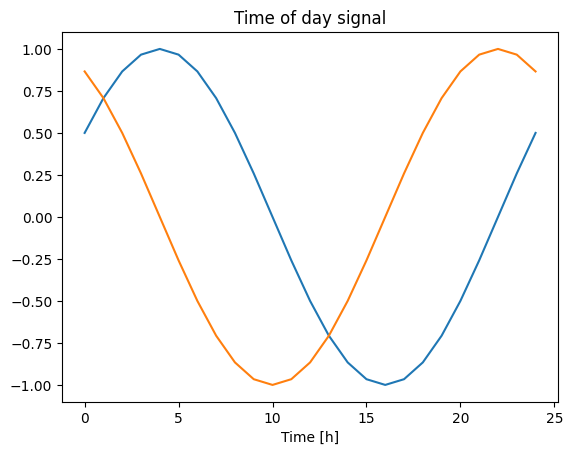

In [190]:
plt.plot(np.array(df['Day sin'])[:25])
plt.plot(np.array(df['Day cos'])[:25])
plt.xlabel('Time [h]')
plt.title('Time of day signal')

In [192]:
df_f = df.drop(columns=['created_at', 'id', 'year', 'month','sht31_temp','sht31_hum'])

In [193]:
df_f.head()

,temperature,humidity,pm25,Day sin,Day cos,Year sin,Year cos
0,0.167691,0.998861,0.767396,0.500000,8.660254e-01,-0.000201,1.000000
1,0.159350,0.998861,0.755365,0.707107,7.071068e-01,0.000516,1.000000
2,0.153644,0.998861,0.732624,0.866025,5.000000e-01,0.001233,0.999999
3,0.159350,0.998861,0.609250,0.965926,2.588190e-01,0.001950,0.999998
4,0.237489,0.998861,0.767396,1.000000,1.944223e-12,0.002666,0.999996


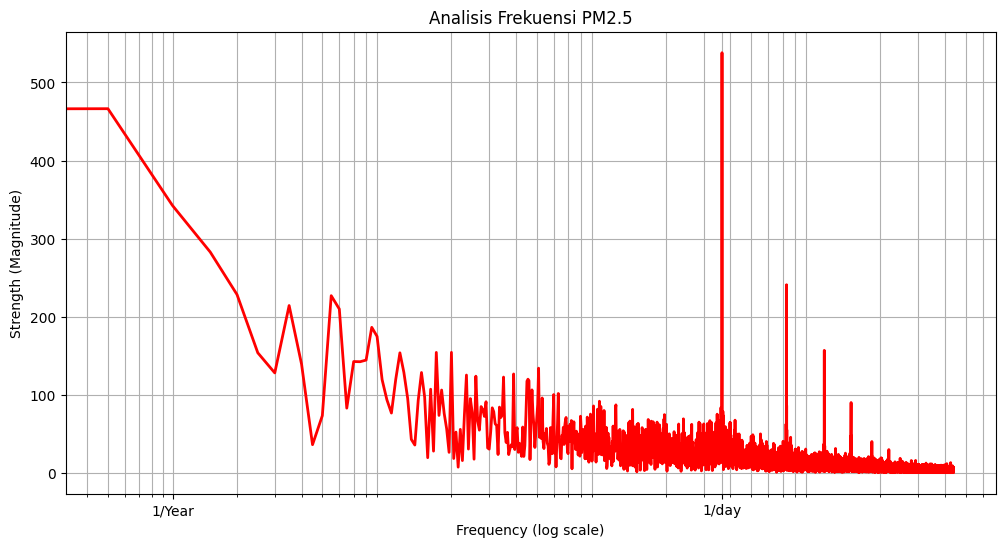

In [195]:
from scipy.fft import rfft, rfftfreq
import matplotlib.pyplot as plt
import numpy as np


data = df_f['pm25'].dropna().values

n = len(data)
yf = rfft(data - np.mean(data))
xf = rfftfreq(n, 1/24)

xf_year = xf * 365.25

plt.figure(figsize=(12, 6))
plt.semilogx(xf_year, np.abs(yf), linewidth=2, color='red')

plt.xticks([1, 365.25], labels=['1/Year', '1/day'])
plt.grid(True, which="both")
plt.xlabel('Frequency (log scale)')
plt.ylabel('Strength (Magnitude)')
plt.title('Analisis Frekuensi PM2.5')
plt.show()

### Split Data

Split the preprocessed df_f dataframe into training (70%), validation (20%), and testing (10%) sets sequentially by calculating the appropriate split indices.

In [197]:
n = len(df_f)
train_df = df_f[0:int(n*0.7)].copy()
val_df = df_f[int(n*0.7):int(n*0.9)].copy()
test_df = df_f[int(n*0.9):].copy()

print(f"Total data: {n}")
print(f"Training data: {len(train_df)}")
print(f"Validation data: {len(val_df)}")
print(f"Testing data: {len(test_df)}")

Total data: 17542
Training data: 12279
Validation data: 3508
Testing data: 1755


In [198]:
total = len(df_f)
print(f"Persentase Training: {(len(train_df)/total)*100:.2f}%")
print(f"Persentase Validation: {(len(val_df)/total)*100:.2f}%")
print(f"Persentase Testing: {(len(test_df)/total)*100:.2f}%")

Persentase Training: 70.00%
Persentase Validation: 20.00%
Persentase Testing: 10.00%


In [212]:
train_raw = train_df.copy()
val_raw = val_df.copy()
test_raw = test_df.copy()

In [213]:
print("\n" + "="*60)
print("STEP 2: ANALISIS OUTLIER (SEBELUM NORMALISASI)")
print("="*60)

cols = ['temperature', 'humidity', 'pm25']

def analyze_outliers(df, name):
    print(f"\n📊 {name}:")
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower) | (df[col] > upper)]

        print(f"  {col}: [{df[col].min():.2f}, {df[col].max():.2f}] | "
              f"outlier: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

analyze_outliers(train_df, "TRAIN (raw)")
analyze_outliers(val_df, "VAL (raw)")
analyze_outliers(test_df, "TEST (raw)")


STEP 2: ANALISIS OUTLIER (SEBELUM NORMALISASI)

📊 TRAIN (raw):
  temperature: [-2.10, 3.24] | outlier: 8 (0.07%)
  humidity: [-3.47, 1.16] | outlier: 10 (0.08%)
  pm25: [-2.09, 3.01] | outlier: 382 (3.11%)

📊 VAL (raw):
  temperature: [-1.80, 3.10] | outlier: 0 (0.00%)
  humidity: [-2.76, 0.62] | outlier: 0 (0.00%)
  pm25: [-1.99, 3.01] | outlier: 0 (0.00%)

📊 TEST (raw):
  temperature: [-0.98, 3.04] | outlier: 197 (11.23%)
  humidity: [-2.33, 0.60] | outlier: 0 (0.00%)
  pm25: [-1.90, 2.61] | outlier: 38 (2.17%)


In [214]:
print("\n" + "="*60)
print("STEP 3: HANDLING OUTLIER (JIKA DIPERLUKAN)")
print("="*60)

# ⚠️ PENTING: Fit parameter di TRAIN, apply ke ALL
HANDLE_OUTLIER = True  # Ganti ke False jika tidak mau handle outlier

if HANDLE_OUTLIER:
    # Method: Capping (Winsorization)
    cap_limits = {}
    for col in cols:
        # Hitung batas dari TRAIN saja!
        lower = train_df[col].quantile(0.01)  # 1st percentile
        upper = train_df[col].quantile(0.99)  # 99th percentile
        cap_limits[col] = (lower, upper)

        print(f"{col}: cap ke [{lower:.2f}, {upper:.2f}]")

        # Apply ke semua split
        train_df[col] = train_df[col].clip(lower, upper)
        val_df[col] = val_df[col].clip(lower, upper)
        test_df[col] = test_df[col].clip(lower, upper)

    print("\nSetelah capping:")
    analyze_outliers(train_df, "TRAIN (capped)")


STEP 3: HANDLING OUTLIER (JIKA DIPERLUKAN)
temperature: cap ke [-1.47, 2.36]
humidity: cap ke [-2.64, 1.16]
pm25: cap ke [-1.81, 3.01]

Setelah capping:

📊 TRAIN (capped):
  temperature: [-1.47, 2.36] | outlier: 0 (0.00%)
  humidity: [-2.64, 1.16] | outlier: 0 (0.00%)
  pm25: [-1.81, 3.01] | outlier: 382 (3.11%)


### Normalize Data

In [215]:
print("\n" + "="*60)
print("STEP 4: NORMALISASI (STANDARDSCALER)")
print("="*60)

# ⚠️ PENTING: Fit HANYA di train, transform ke val & test
scaler = StandardScaler()
scaler.fit(train_df[cols])  # ← HANYA TRAIN!

print("Parameter scaler (dari train):")
for i, col in enumerate(cols):
    print(f"  {col}: mean={scaler.mean_[i]:.3f}, std={scaler.scale_[i]:.3f}")

# Transform semua
train_df[cols] = scaler.transform(train_df[cols])
val_df[cols] = scaler.transform(val_df[cols])
test_df[cols] = scaler.transform(test_df[cols])


STEP 4: NORMALISASI (STANDARDSCALER)
Parameter scaler (dari train):
  temperature: mean=-0.000, std=0.992
  humidity: mean=0.002, std=0.993
  pm25: mean=0.001, std=0.997


In [216]:
print("\n" + "="*60)
print("STEP 5: VERIFIKASI SETELAH NORMALISASI")
print("="*60)

def verify_normalized(df, name):
    print(f"\n✅ {name}:")
    for col in cols:
        print(f"  {col}: μ={df[col].mean():.3f}, σ={df[col].std():.3f}, "
              f"range=[{df[col].min():.2f}, {df[col].max():.2f}]")

verify_normalized(train_df, "TRAIN")
verify_normalized(val_df, "VAL")
verify_normalized(test_df, "TEST")


STEP 5: VERIFIKASI SETELAH NORMALISASI

✅ TRAIN:
  temperature: μ=0.000, σ=1.000, range=[-1.48, 2.38]
  humidity: μ=-0.000, σ=1.000, range=[-2.66, 1.17]
  pm25: μ=0.000, σ=1.000, range=[-1.81, 3.02]

✅ VAL:
  temperature: μ=0.348, σ=1.006, range=[-1.48, 2.38]
  humidity: μ=-0.703, σ=0.757, range=[-2.66, 0.62]
  pm25: μ=0.367, σ=1.001, range=[-1.81, 3.02]

✅ TEST:
  temperature: μ=0.149, σ=0.824, range=[-0.99, 2.38]
  humidity: μ=-0.579, σ=0.739, range=[-2.35, 0.60]
  pm25: μ=-0.058, σ=0.806, range=[-1.81, 2.62]


In [217]:
print("\n" + "="*60)
print("STEP 6: SIMPAN HASIL")
print("="*60)

# Data siap digunakan untuk modeling
print("✅ train_df, val_df, test_df siap digunakan!")

# Simpan scaler untuk inference nanti
import joblib
joblib.dump(scaler, 'scaler.pkl')
print("✅ Scaler disimpan ke 'scaler.pkl'")


STEP 6: SIMPAN HASIL
✅ train_df, val_df, test_df siap digunakan!
✅ Scaler disimpan ke 'scaler.pkl'


/tmp/ipython-input-3028559161.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(x='Column', y='Normalized Value', data=df_melted, palette='viridis')


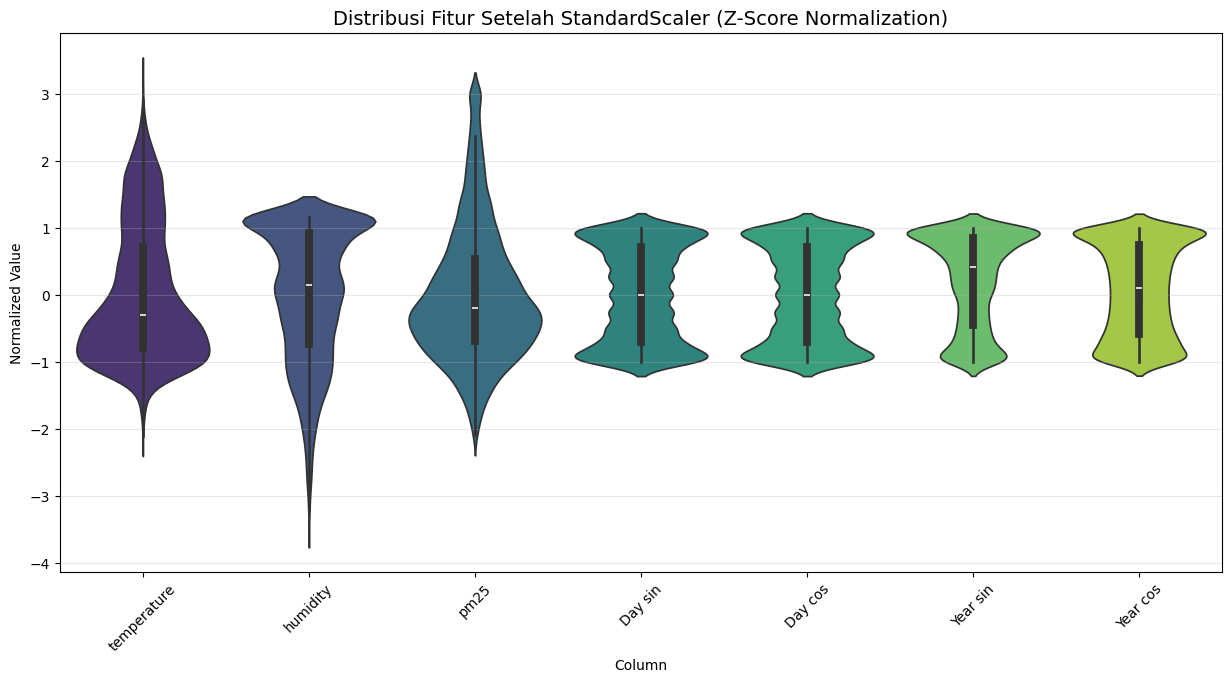

In [205]:
import seaborn as sns
import matplotlib.pyplot as plt

features_to_plot = ['temperature', 'humidity', 'pm25', 'Day sin', 'Day cos', 'Year sin', 'Year cos']
df_melted = train_df[features_to_plot].melt(var_name='Column', value_name='Normalized Value')
plt.figure(figsize=(15, 7))
ax = sns.violinplot(x='Column', y='Normalized Value', data=df_melted, palette='viridis')
plt.xticks(rotation=45)
plt.title('Distribusi Fitur Setelah StandardScaler (Z-Score Normalization)', fontsize=14)
plt.grid(axis='y', alpha=0.3)

plt.show()

#### Data windowing

In [175]:
# Lakukan clipping pada persentil 99 untuk menjaga skala agar tidak rusak oleh outlier
p99 = train_df['pm25'].quantile(0.99)
train_df['pm25'] = train_df['pm25'].clip(upper=p99)
val_df['pm25'] = val_df['pm25'].clip(upper=p99)
test_df['pm25'] = test_df['pm25'].clip(upper=p99)

print(f"Data clipping selesai. Nilai maksimal PM2.5 dibatasi pada: {p99}")

Data clipping selesai. Nilai maksimal PM2.5 dibatasi pada: 2.9937133465123993


In [176]:
import numpy as np
import tensorflow as tf

class WindowGenerator():
  def __init__(self, input_width, label_width, shift,
               train_df, val_df, test_df,
               label_columns=None):
    self.train_df = train_df
    self.val_df = val_df
    self.test_df = test_df

    self.label_columns = label_columns
    if label_columns is not None:
      self.label_columns_indices = {name: i for i, name in enumerate(label_columns)}
    self.column_indices = {name: i for i, name in enumerate(train_df.columns)}

    self.input_width = input_width
    self.label_width = label_width
    self.shift = shift
    self.total_window_size = input_width + shift

    self.input_slice = slice(0, input_width)
    self.input_indices = np.arange(self.total_window_size)[self.input_slice]
    self.label_start = self.total_window_size - self.label_width
    self.labels_slice = slice(self.label_start, None)
    self.label_indices = np.arange(self.total_window_size)[self.labels_slice]

  def split_window(self, features):
    inputs = features[:, self.input_slice, :]
    labels = features[:, self.labels_slice, :]
    if self.label_columns is not None:
      labels = tf.stack(
          [labels[:, :, self.column_indices[name]] for name in self.label_columns],
          axis=-1)

    inputs.set_shape([None, self.input_width, None])
    labels.set_shape([None, self.label_width, None])
    return inputs, labels

  def make_dataset(self, data, shuffle=True):
    data = np.array(data, dtype=np.float32)
    ds = tf.keras.utils.timeseries_dataset_from_array(
        data=data,
        targets=None,
        sequence_length=self.total_window_size,
        sequence_stride=1,
        shuffle=shuffle,
        batch_size=32,) # Batch size 32 umum digunakan untuk stabilitas
    ds = ds.map(self.split_window)
    return ds

  @property
  def train(self):
    return self.make_dataset(self.train_df, shuffle=True)

  @property
  def val(self):
    return self.make_dataset(self.val_df, shuffle=False)

  @property
  def test(self):
    return self.make_dataset(self.test_df, shuffle=False)

In [177]:
# Memberikan konteks sejarah yang lebih panjang (72 jam) untuk akurasi lebih baik
multi_window = WindowGenerator(
    input_width=72,
    label_width=24,
    shift=24,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    label_columns=['pm25']
)

### Training Model


#### Arsitekture Model

In [178]:
multi_lstm_model = tf.keras.Sequential([
    # Layer 1: Menangkap pola temporal awal
    tf.keras.layers.LSTM(128, return_sequences=True, input_shape=(72, 7)),
    tf.keras.layers.Dropout(0.3),

    # Layer 2: Meringkas pola ke fitur yang lebih abstrak
    tf.keras.layers.LSTM(64, return_sequences=False),
    tf.keras.layers.Dropout(0.3),

    # Dense Layer untuk interpretasi akhir
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(24 * 1),
    tf.keras.layers.Reshape([24, 1])
])

multi_lstm_model.compile(
    loss=tf.keras.losses.MeanSquaredError(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=[tf.keras.metrics.MeanAbsoluteError()]
)

# Training dengan EarlyStopping
history = multi_lstm_model.fit(
    multi_window.train,
    epochs=50,
    validation_data=multi_window.val,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, mode='min')]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
381/381 ━━━━━━━━━━━━━━━━━━━━ 44s 105ms/step - loss: 0.6695 - mean_absolute_error: 0.6286 - val_loss: 0.8370 - val_mean_absolute_error: 0.7067
Epoch 2/50
381/381 ━━━━━━━━━━━━━━━━━━━━ 40s 106ms/step - loss: 0.5358 - mean_absolute_error: 0.5604 - val_loss: 0.8630 - val_mean_absolute_error: 0.7136
Epoch 3/50
381/381 ━━━━━━━━━━━━━━━━━━━━ 41s 108ms/step - loss: 0.4723 - mean_absolute_error: 0.5277 - val_loss: 0.9737 - val_mean_absolute_error: 0.7555
Epoch 4/50
381/381 ━━━━━━━━━━━━━━━━━━━━ 39s 103ms/step - loss: 0.4041 - mean_absolute_error: 0.4882 - val_loss: 0.9567 - val_mean_absolute_error: 0.7502
Epoch 5/50
381/381 ━━━━━━━━━━━━━━━━━━━━ 37s 97ms/step - loss: 0.3513 - mean_absolute_error: 0.4534 - val_loss: 1.0218 - val_mean_absolute_error: 0.7789
Epoch 6/50
381/381 ━━━━━━━━━━━━━━━━━━━━ 37s 98ms/step - loss: 0.3073 - mean_absolute_error: 0.4235 - val_loss: 1.0296 - val_mean_absolute_error: 0.7776


In [179]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Prediksi pada data test
all_inputs, all_labels = [], []
for inputs, labels in multi_window.test:
    all_inputs.append(inputs)
    all_labels.append(labels)

y_pred = multi_lstm_model.predict(np.concatenate(all_inputs))
y_true = np.concatenate(all_labels)

# Ambil parameter StandardScaler untuk PM2.5 (asumsi indeks 2)
pm25_idx = 2
pm25_mean = scaler.mean_[pm25_idx]
pm25_std = scaler.scale_[pm25_idx]

# Balikkan ke satuan asli
y_true_orig = (y_true.flatten() * pm25_std) + pm25_mean
y_pred_orig = (y_pred.flatten() * pm25_std) + pm25_mean

print(f"R2 Score: {r2_score(y_true_orig, y_pred_orig):.4f}")
print(f"MAE: {mean_absolute_error(y_true_orig, y_pred_orig):.2f} ug/m3")

52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step
R2 Score: -0.2846
MAE: 0.10 ug/m3


In [182]:
# CARA MEMPERBAIKI SCALER (Lakukan di awal sebelum split)
from sklearn.preprocessing import StandardScaler

# Pastikan df_consistent adalah data asli HASIL INTERPOLASI (Satuan ug/m3)
# Bukan data yang sudah pernah di-scale
scaler_asli = StandardScaler()
columns_to_scale = ['temperature', 'humidity', 'pm25']

# Fit hanya pada data training mentah
scaler_asli.fit(train_df_asli[columns_to_scale])

# Simpan Mean & Std yang benar-benar fisik
pm25_mean_fisik = scaler_asli.mean_[2] # Indeks pm25
pm25_std_fisik = scaler_asli.scale_[2]

print(f"Mean Fisik Seharusnya: {pm25_mean_fisik} ug/m3")

NameError: name 'train_df_asli' is not defined

#### Training Model

In [164]:

# early_stopping = tf.keras.callbacks.EarlyStopping(
#     monitor='val_loss',
#     patience=5,
#     mode='min'
# )

# history = multi_lstm_model.fit(
#     multi_window.train,
#     epochs=50,
#     validation_data=multi_window.val,
#     callbacks=[early_stopping]
# )

Epoch 1/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.7107 - mean_absolute_error: 0.6423 - val_loss: 0.8779 - val_mean_absolute_error: 0.7196
Epoch 2/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 0.5732 - mean_absolute_error: 0.5718 - val_loss: 0.8377 - val_mean_absolute_error: 0.7023
Epoch 3/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.5374 - mean_absolute_error: 0.5527 - val_loss: 0.8450 - val_mean_absolute_error: 0.6984
Epoch 4/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.5169 - mean_absolute_error: 0.5400 - val_loss: 0.8323 - val_mean_absolute_error: 0.6921
Epoch 5/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.4973 - mean_absolute_error: 0.5300 - val_loss: 0.8533 - val_mean_absolute_error: 0.6991
Epoch 6/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.4749 - mean_absolute_error: 0.5193 - val_loss: 0.8372 - val_mean_absolute_error: 0.6909
Epoch 7/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.4574 - mean_absolute_error: 0.

#### Evaluation

In [173]:
eval_result = multi_lstm_model.evaluate(multi_window.test)
print(f"Test MAE: {eval_result[1]}")

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5665 - mean_absolute_error: 0.5932
Test MAE: 0.5908728837966919


#### rediksi dan Inverse Transform

In [154]:
# Mengambil satu batch contoh dari data test
for example_inputs, example_labels in multi_window.test.take(1):
    predictions = multi_lstm_model(example_inputs)

    # Ambil hasil prediksi pertama dalam batch
    pred_single = predictions[0].numpy() # shape (24, 1)
    true_single = example_labels[0].numpy() # shape (24, 1)

    # Balikkan skala menggunakan scaler yang sudah Anda fit sebelumnya
    # Karena scaler.inverse_transform mengharapkan 3 kolom (temp, hum, pm25),
    # Anda perlu melakukan trik sedikit untuk mengembalikan nilai PM25 saja.

    # Contoh sederhana inverse PM25 (sesuaikan dengan index kolom pm25):
    # Jika menggunakan MinMaxScaler: x_asli = x_scaled * (max - min) + min
    max_val = scaler.data_max_[2] # index 2 adalah pm25
    min_val = scaler.data_min_[2]

    pred_actual = pred_single * (max_val - min_val) + min_val
    true_actual = true_single * (max_val - min_val) + min_val